# Todo

- Explore the bid-ask spread across different maturities and strikes
- Explore the bid-ask spread across different underlying assets
- Explore the spread wrt to vega, implied volatility, etc.
- Explore the spread for a single day
- See the impact of transaction cost on backtest result
  - Try implementing another tcost model
- Backtest delta hedging strategies
- Backtest delta-gamma hedging strategies
  - Try other variant on calls or puts.


In [1]:
# Setup auto reload
%load_ext autoreload
%autoreload 2

In [13]:
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rc("font", **{"size": 18})
import numpy as np
from warnings import filterwarnings
import logging

logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")

filterwarnings("ignore")

import investment_lab.option_selection as option_selection
import investment_lab.backtest as backtest
from investment_lab.data.option_db import OptionLoader
from investment_lab.data.rates_db import USRatesLoader
from investment_lab.option_trade import OptionTrade, DeltaHedgedOptionTrade, DeltaGammaHedgedOptionTrade, VarianceSwap
from investment_lab.backtest import StrategyBacktester, BacktesterBidAskFromData, BacktesterFixedRelativeBidAsk

from investment_lab.pricing.black_scholes import black_scholes_price, black_scholes_greeks
from investment_lab.rates import compute_forward
from investment_lab import option_strategies as option_strategies
from investment_lab.option_selection import select_closest_maturity

In [7]:
df_options = OptionLoader.load_data(datetime(2020, 1, 4), datetime(2022, 12, 4), process_kwargs={"ticker": "SPY"})
df_options.head()

2026-02-13 10:38:11,348 | INFO | Reading between 2020-01-04 00:00:00 2022-12-04 00:00:00 from ..//data/optiondb_2016_2023.parquet with None
2026-02-13 10:38:19,154 | INFO | Processing with {'ticker': 'SPY'}
2026-02-13 10:38:19,154 | INFO | Potentially add extra field with None


,spot,strike,expiration,delta,gamma,vega,theta,rho,implied_volatility,bid,ask,volume,call_put,option_id,mid,ticker,date,day_to_expiration,moneyness
5867,323.68,265.0,2020-01-06,1.0,0.0,0.0,0.0,0.0,0.0,58.68,58.68,0.0,C,SPY 20200106C265,58.68,SPY,2020-01-06,0,0.818710
5868,323.68,270.0,2020-01-06,1.0,0.0,0.0,0.0,0.0,0.0,53.68,53.68,0.0,C,SPY 20200106C270,53.68,SPY,2020-01-06,0,0.834157
5869,323.68,275.0,2020-01-06,1.0,0.0,0.0,0.0,0.0,0.0,48.68,48.68,0.0,C,SPY 20200106C275,48.68,SPY,2020-01-06,0,0.849605
5870,323.68,280.0,2020-01-06,1.0,0.0,0.0,0.0,0.0,0.0,43.68,43.68,41.0,C,SPY 20200106C280,43.68,SPY,2020-01-06,0,0.865052
5871,323.68,285.0,2020-01-06,1.0,0.0,0.0,0.0,0.0,0.0,38.68,38.68,1.0,C,SPY 20200106C285,38.68,SPY,2020-01-06,0,0.880499


In [11]:
df_one_day = df_options[df_options["date"] == "2020-01-06"]
df_one_day.head()

,spot,strike,expiration,delta,gamma,vega,theta,rho,implied_volatility,bid,ask,volume,call_put,option_id,mid,ticker,date,day_to_expiration,moneyness
5867,323.68,265.0,2020-01-06,1.0,0.0,0.0,0.0,0.0,0.0,58.68,58.68,0.0,C,SPY 20200106C265,58.68,SPY,2020-01-06,0,0.818710
5868,323.68,270.0,2020-01-06,1.0,0.0,0.0,0.0,0.0,0.0,53.68,53.68,0.0,C,SPY 20200106C270,53.68,SPY,2020-01-06,0,0.834157
5869,323.68,275.0,2020-01-06,1.0,0.0,0.0,0.0,0.0,0.0,48.68,48.68,0.0,C,SPY 20200106C275,48.68,SPY,2020-01-06,0,0.849605
5870,323.68,280.0,2020-01-06,1.0,0.0,0.0,0.0,0.0,0.0,43.68,43.68,41.0,C,SPY 20200106C280,43.68,SPY,2020-01-06,0,0.865052
5871,323.68,285.0,2020-01-06,1.0,0.0,0.0,0.0,0.0,0.0,38.68,38.68,1.0,C,SPY 20200106C285,38.68,SPY,2020-01-06,0,0.880499


In [8]:
legs = {"day_to_expiry_target": 30, "strike_spacing": 2, "weight": 1, "rebal_week_day": [2]}

In [16]:
selected_option_df = select_closest_maturity(df_one_day, day_to_expiry_target=30)
selected_option_df = selected_option_df.loc[
    ((selected_option_df["call_put"] == "P") & (selected_option_df["moneyness"] <= 1.0))
    | ((selected_option_df["call_put"] == "C") & (selected_option_df["moneyness"] >= 1.0))
]
selected_option_df.shape

(43, 19)

In [56]:
selected_option_df_pvt = (
    selected_option_df.pivot_table(index=["date", "expiration", "strike"], columns="call_put", values="mid").reset_index().sort_values("strike")
)

selected_option_df_pvt["dK"] = selected_option_df_pvt["strike"].diff()
selected_option_df_pvt["integrand_C"] = ((selected_option_df_pvt["dK"] / 2) * selected_option_df_pvt["C"]) / selected_option_df_pvt["strike"] ** 2
selected_option_df_pvt["integrand_P"] = ((selected_option_df_pvt["dK"] / 2) * selected_option_df_pvt["P"]) / selected_option_df_pvt["strike"] ** 2
selected_option_df_pvt

call_put,date,expiration,strike,C,P,dK,integrand_C,integrand_P
0,2020-01-06,2020-02-05,290.0,NaN,0.315,NaN,NaN,NaN
1,2020-01-06,2020-02-05,295.0,NaN,0.435,5.0,NaN,0.000012
2,2020-01-06,2020-02-05,300.0,NaN,0.640,5.0,NaN,0.000018
3,2020-01-06,2020-02-05,305.0,NaN,0.930,5.0,NaN,0.000025
4,2020-01-06,2020-02-05,306.0,NaN,1.010,1.0,NaN,0.000005
5,2020-01-06,2020-02-05,307.0,NaN,1.095,1.0,NaN,0.000006
6,2020-01-06,2020-02-05,308.0,NaN,1.185,1.0,NaN,0.000006
7,2020-01-06,2020-02-05,309.0,NaN,1.290,1.0,NaN,0.000007
8,2020-01-06,2020-02-05,310.0,NaN,1.380,1.0,NaN,0.000007
9,2020-01-06,2020-02-05,311.0,NaN,1.475,1.0,NaN,0.000008


In [59]:
selected_option_df_pvt["integrand_P"].dropna().sum() + selected_option_df_pvt["integrand_C"].dropna().sum()

np.float64(0.0003485270608369708)

In [51]:
from investment_lab.data.option_db import extract_spot_from_options


df_rates = USRatesLoader.load_data(datetime(2020, 1, 6), datetime(2020, 1, 6))
df_rates.head()
df_spot = extract_spot_from_options(df_options)
df_spot.head()

2026-02-13 10:59:22,710 | INFO | Reading between 2020-01-06 00:00:00 2020-01-06 00:00:00 from ..//data/par-yield-curve-rates-2020-2023.csv with None
2026-02-13 10:59:22,737 | INFO | Processing with None
2026-02-13 10:59:22,740 | INFO | Potentially add extra field with None


,date,spot
0,2020-01-06,323.68
1,2020-01-07,322.74
2,2020-01-08,324.39
3,2020-01-09,326.59
4,2020-01-10,325.64


In [61]:
F_t = 323.68 * np.exp(0.0154 * 30 / 365)
integrand = selected_option_df_pvt["integrand_P"].dropna().sum() + selected_option_df_pvt["integrand_C"].dropna().sum()
integrand * 2 * np.exp(0.0154 * (30 / 365)) / (30 / 365)  # - ((F_t / selected_option_df_pvt["strike"].min()) - 1) ** 2 / (30 / 365)

np.float64(0.008491566577073565)

In [71]:
df = VarianceSwap.generate_trades(
    datetime(2020, 1, 2),
    datetime(2022, 4, 30),
    tickers="SPY",
    legs=[{"day_to_expiry_target": 30, "strike_spacing": 2, "weight": -1, "rebal_week_day": [2]}],
    cost_neutral=False,
)
df

2026-02-13 11:19:48,063 | INFO | Loading option data from 2020-01-02 00:00:00 to 2022-04-30 00:00:00
2026-02-13 11:19:48,064 | INFO | Reading between 2020-01-02 00:00:00 2022-04-30 00:00:00 from ..//data/optiondb_2016_2023.parquet with None
2026-02-13 11:19:55,643 | INFO | Processing with {'ticker': 'SPY'}
2026-02-13 11:19:55,643 | INFO | Potentially add extra field with None
2026-02-13 11:20:00,346 | INFO | Preprocessing option data.
2026-02-13 11:20:00,360 | INFO | Selecting options for leg: VARIANCE SWAP using the rules:
{'day_to_expiry_target': 30}
2026-02-13 11:20:02,060 | INFO | Converting 19358 df_trades to daily time series
2026-02-13 11:20:12,561 | INFO | Forward filling option data for df
2026-02-13 11:20:25,806 | INFO | Reading between 2020-01-08 00:00:00 2022-04-29 00:00:00 from ..//data/par-yield-curve-rates-2020-2023.csv with None
2026-02-13 11:20:25,848 | INFO | Processing with None
2026-02-13 11:20:25,848 | INFO | Potentially add extra field with None


,date,option_id,entry_date,leg_name,weight,ticker
0,2020-01-08,SPY 20200207C325,2020-01-08,VARIANCE SWAP,0.0,SPY
1,2020-01-08,SPY 20200207C326,2020-01-08,VARIANCE SWAP,0.0,SPY
2,2020-01-08,SPY 20200207C327,2020-01-08,VARIANCE SWAP,0.0,SPY
3,2020-01-08,SPY 20200207C328,2020-01-08,VARIANCE SWAP,0.0,SPY
4,2020-01-08,SPY 20200207C329,2020-01-08,VARIANCE SWAP,0.0,SPY
...,...,...,...,...,...,...
398663,2022-04-29,SPY 20220527P413,2022-04-27,VARIANCE SWAP,0.0,SPY
398664,2022-04-29,SPY 20220527P414,2022-04-27,VARIANCE SWAP,0.0,SPY
398665,2022-04-29,SPY 20220527P415,2022-04-27,VARIANCE SWAP,0.0,SPY
398666,2022-04-29,SPY 20220527P416,2022-04-27,VARIANCE SWAP,0.0,SPY


In [72]:
backtest_result = StrategyBacktester(df).compute_backtest()
backtest_result

2026-02-13 11:20:34,328 | INFO | Shifting +1 business to ensure valid trading result.
2026-02-13 11:20:34,355 | INFO | Reading between 2020-01-08 00:00:00 2022-04-29 00:00:00 from ..//data/optiondb_2016_2023.parquet with None
2026-02-13 11:20:41,403 | INFO | Processing with {'ticker': ['SPY']}
2026-02-13 11:20:41,403 | INFO | Potentially add extra field with None
2026-02-13 11:20:50,710 | INFO | Forward filling option data for df
2026-02-13 11:21:02,083 | INFO | No transaction cost applied here.
2026-02-13 11:21:02,347 | INFO | Computing period to period difference, for P&L calculations.
2026-02-13 11:21:02,502 | INFO | Append previous period greeks for P&L calculations.
2026-02-13 11:21:06,004 | INFO | Starting backtest computation over 603 unique dates.
100%|██████████| 603/603 [00:06<00:00, 91.01it/s] 
2026-02-13 11:21:12,664 | INFO | Backtest computation completed.


<Axes: >

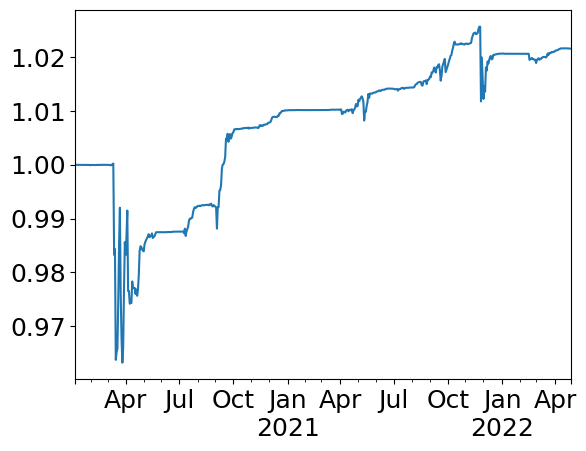

In [73]:
(backtest_result.pnl["pnl"] - backtest_result.pnl["delta_pnl"]).cumsum().add(1).plot()

<Axes: >

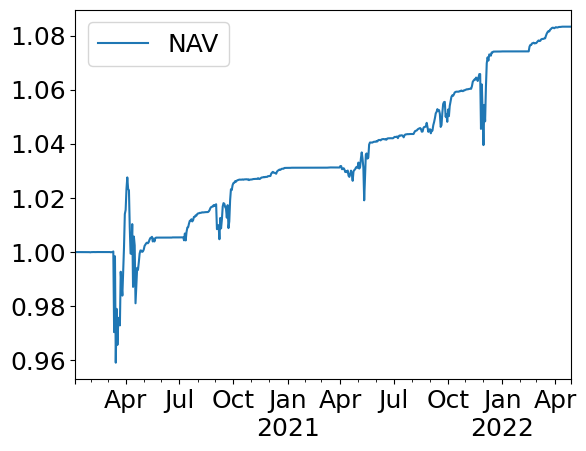

In [74]:
backtest_result.nav.plot()